In [23]:
# ============================================
# CELL 1: Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")


✅ All libraries imported successfully!
Pandas version: 3.0.1
Numpy version: 2.4.3


In [26]:
# ============================================
# CELL 2: Load Intrusion Detection Dataset
# ============================================
df_intrusion = pd.read_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\raw\intrusion_data.csv')

print("✅ Intrusion dataset loaded!")
print(f"Rows: {df_intrusion.shape[0]:,}")
print(f"Columns: {df_intrusion.shape[1]}")
df_intrusion.head()

✅ Intrusion dataset loaded!
Rows: 692,703
Columns: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [27]:
# ============================================
# CELL 3: Load Phishing Dataset
# ============================================
df_phishing = pd.read_csv(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\raw\phishing_data.csv')

print("✅ Phishing dataset loaded!")
print(f"Rows: {df_phishing.shape[0]:,}")
print(f"Columns: {df_phishing.shape[1]}")
df_phishing.head()

✅ Phishing dataset loaded!
Rows: 235,795
Columns: 56


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [28]:
# ============================================
# CELL 4: Basic Info & Missing Values
# ============================================
print("=" * 50)
print("INTRUSION DATASET - MISSING VALUES")
print("=" * 50)
missing_intrusion = df_intrusion.isnull().sum()
missing_intrusion_pct = (missing_intrusion / len(df_intrusion)) * 100
print(f"Total missing values: {missing_intrusion.sum()}")
print(f"Columns with missing values: {(missing_intrusion > 0).sum()}")

print("\n" + "=" * 50)
print("PHISHING DATASET - MISSING VALUES")
print("=" * 50)
missing_phishing = df_phishing.isnull().sum()
print(f"Total missing values: {missing_phishing.sum()}")
print(f"Columns with missing values: {(missing_phishing > 0).sum()}")

INTRUSION DATASET - MISSING VALUES
Total missing values: 1008
Columns with missing values: 1

PHISHING DATASET - MISSING VALUES
Total missing values: 0
Columns with missing values: 0


In [29]:
# ============================================
# CELL 5: Check Target Labels
# ============================================
print("INTRUSION - Attack Types:")
print(df_intrusion[' Label'].value_counts())

print("\nPHISHING - Class Distribution:")
print(df_phishing['label'].value_counts())

INTRUSION - Attack Types:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

PHISHING - Class Distribution:
label
1    134850
0    100945
Name: count, dtype: int64


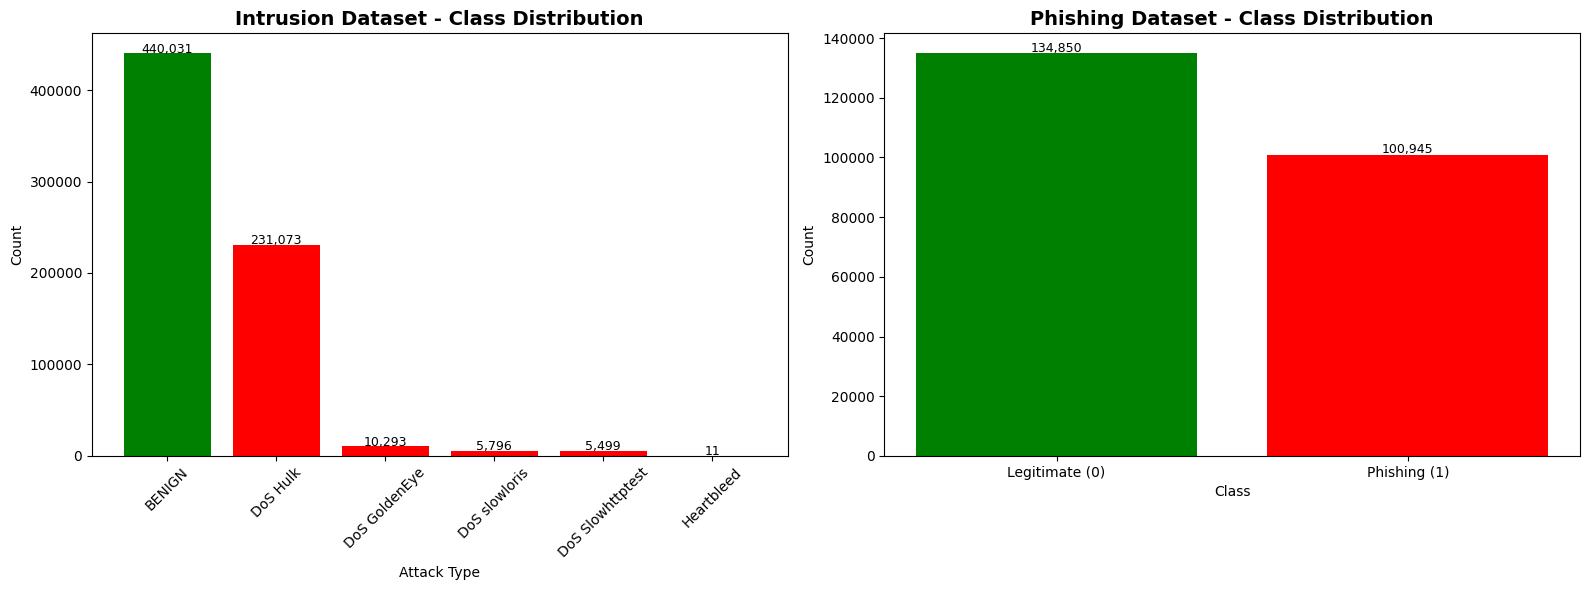

✅ Plot saved!


In [30]:
# ============================================
# CELL 6: Class Distribution Plots
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Intrusion plot
intrusion_counts = df_intrusion[' Label'].value_counts()
axes[0].bar(intrusion_counts.index, intrusion_counts.values, 
            color=['green' if x == 'BENIGN' else 'red' for x in intrusion_counts.index])
axes[0].set_title('Intrusion Dataset - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(intrusion_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Phishing plot
phishing_counts = df_phishing['label'].value_counts()
axes[1].bar(['Legitimate (0)', 'Phishing (1)'], phishing_counts.values,
            color=['green', 'red'])
axes[1].set_title('Phishing Dataset - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
for i, v in enumerate(phishing_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\class_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

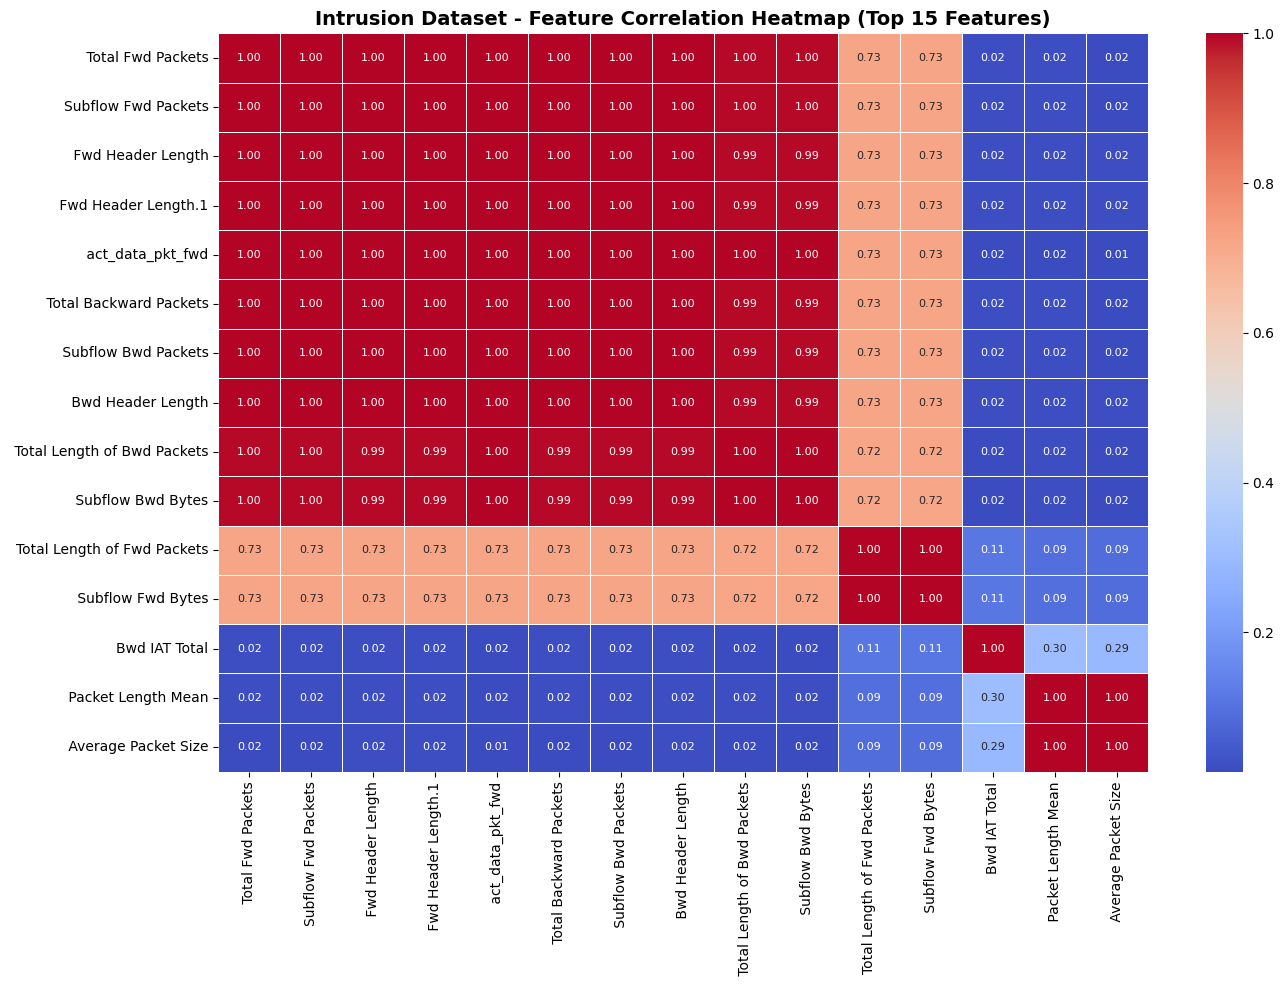

✅ Heatmap saved!


In [31]:
# ============================================
# CELL 7: Correlation Heatmap (Intrusion)
# ============================================

# Select only numeric columns
numeric_intrusion = df_intrusion.select_dtypes(include=[np.number])

# Take top 15 most correlated features for readability
corr_matrix = numeric_intrusion.corr().abs()
top_features = corr_matrix.nlargest(15, ' Total Fwd Packets').index

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_intrusion[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 8})
plt.title('Intrusion Dataset - Feature Correlation Heatmap (Top 15 Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

In [32]:
# ============================================
# CELL 8: Summary Statistics
# ============================================
print("=" * 50)
print("INTRUSION DATASET - SUMMARY STATISTICS")
print("=" * 50)
print(df_intrusion.describe().round(2).to_string())

print("\n" + "=" * 50)
print("PHISHING DATASET - SUMMARY STATISTICS")
print("=" * 50)
print(df_phishing.describe().round(2).to_string())

INTRUSION DATASET - SUMMARY STATISTICS
        Destination Port   Flow Duration   Total Fwd Packets   Total Backward Packets  Total Length of Fwd Packets   Total Length of Bwd Packets   Fwd Packet Length Max   Fwd Packet Length Min   Fwd Packet Length Mean   Fwd Packet Length Std  Bwd Packet Length Max   Bwd Packet Length Min   Bwd Packet Length Mean   Bwd Packet Length Std  Flow Bytes/s   Flow Packets/s   Flow IAT Mean   Flow IAT Std   Flow IAT Max   Flow IAT Min  Fwd IAT Total   Fwd IAT Mean   Fwd IAT Std   Fwd IAT Max   Fwd IAT Min  Bwd IAT Total   Bwd IAT Mean   Bwd IAT Std   Bwd IAT Max   Bwd IAT Min  Fwd PSH Flags   Bwd PSH Flags   Fwd URG Flags   Bwd URG Flags   Fwd Header Length   Bwd Header Length  Fwd Packets/s   Bwd Packets/s   Min Packet Length   Max Packet Length   Packet Length Mean   Packet Length Std   Packet Length Variance  FIN Flag Count   SYN Flag Count   RST Flag Count   PSH Flag Count   ACK Flag Count   URG Flag Count   CWE Flag Count   ECE Flag Count   Down/Up Ra

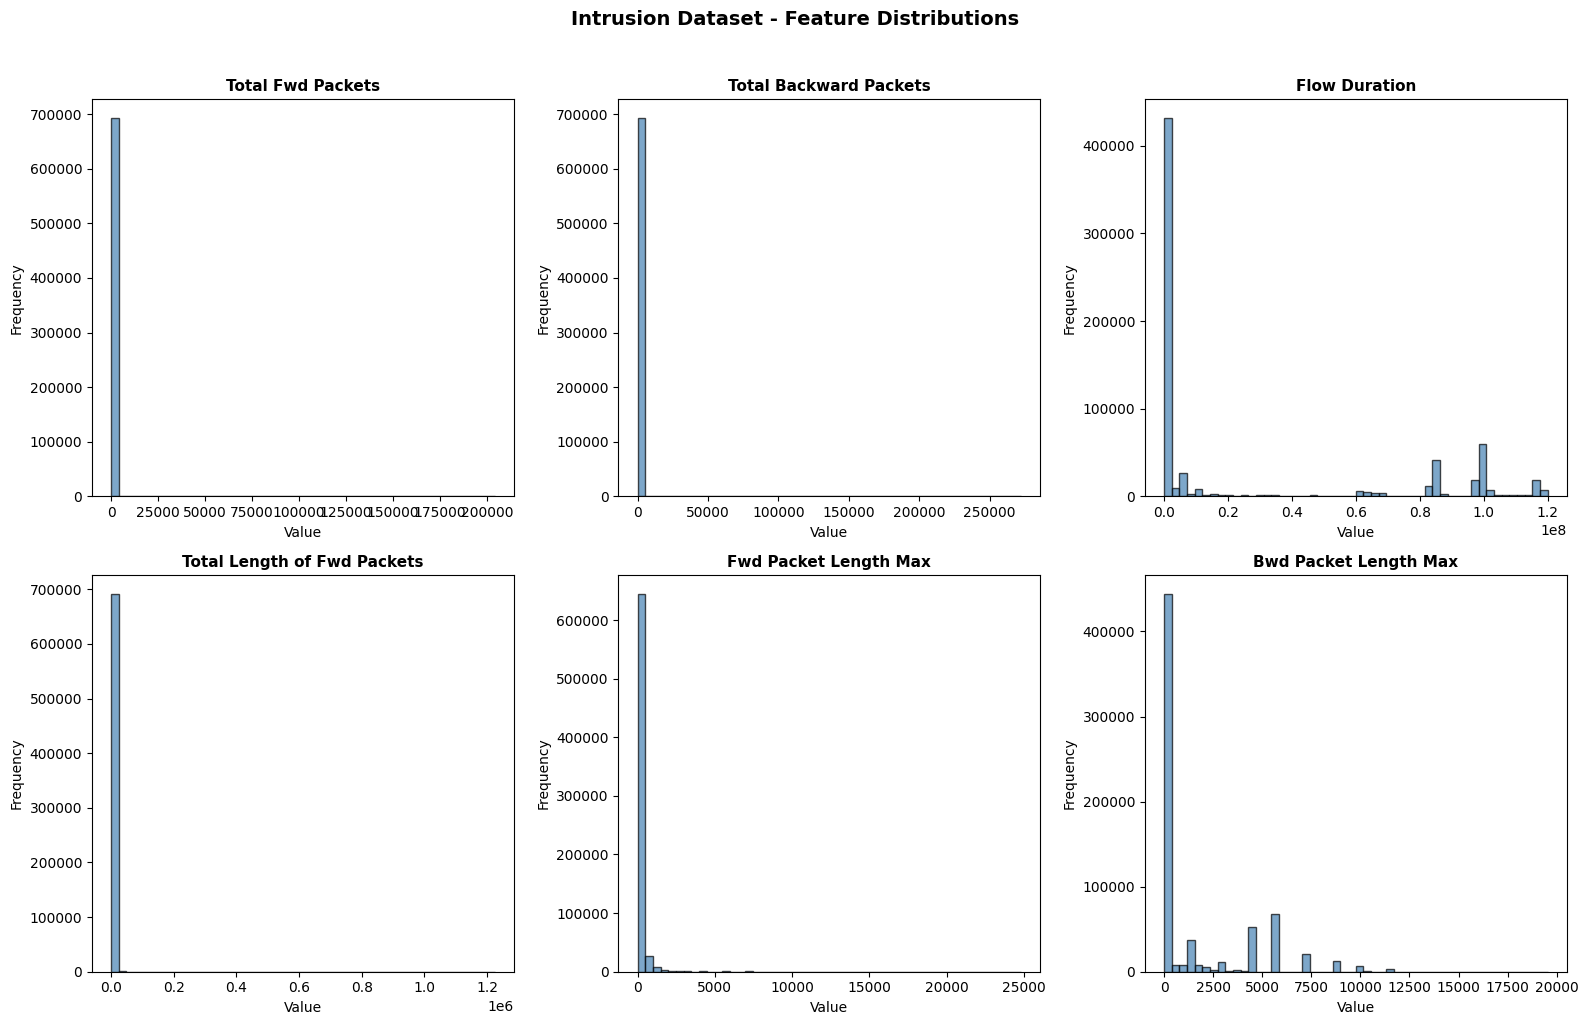

✅ Feature distributions saved!


In [34]:
# ============================================
# CELL 9: Feature Distribution (Top 6 Features)
# ============================================
top_6 = [' Total Fwd Packets', ' Total Backward Packets',
         ' Flow Duration', 'Total Length of Fwd Packets',
         ' Fwd Packet Length Max', 'Bwd Packet Length Max']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_6):
    axes[i].hist(df_intrusion[col].dropna(), bins=50, 
                 color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col.strip()}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Intrusion Dataset - Feature Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature distributions saved!")

In [35]:
# ============================================
# CELL 10: Save EDA Summary to Text File
# ============================================
summary = f"""
EDA SUMMARY REPORT
==================
INTRUSION DATASET:
- Rows: {df_intrusion.shape[0]:,}
- Columns: {df_intrusion.shape[1]}
- Missing values: {df_intrusion.isnull().sum().sum()}
- Attack types: {df_intrusion[' Label'].nunique()}
- Class distribution:
{df_intrusion[' Label'].value_counts().to_string()}

PHISHING DATASET:
- Rows: {df_phishing.shape[0]:,}
- Columns: {df_phishing.shape[1]}
- Missing values: {df_phishing.isnull().sum().sum()}
- Classes: {df_phishing['label'].nunique()}
- Class distribution:
{df_phishing['label'].value_counts().to_string()}

FIGURES GENERATED:
1. class_distribution.png
2. correlation_heatmap.png
3. feature_distributions.png
"""

with open(r'C:\Users\Kshaunish\cyber-xai-ml-project\data\processed\eda_summary.txt', 'w') as f:
    f.write(summary)

print("✅ EDA Summary saved!")
print(summary)

✅ EDA Summary saved!

EDA SUMMARY REPORT
INTRUSION DATASET:
- Rows: 692,703
- Columns: 79
- Missing values: 1008
- Attack types: 6
- Class distribution:
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11

PHISHING DATASET:
- Rows: 235,795
- Columns: 56
- Missing values: 0
- Classes: 2
- Class distribution:
label
1    134850
0    100945

FIGURES GENERATED:
1. class_distribution.png
2. correlation_heatmap.png
3. feature_distributions.png

